# Fine-Tuned Gesture Recognition
**Fixed notebook** — all critical bugs resolved. Run cells top-to-bottom.

Fixes applied:
1. `device` defined at the very top (Cell 2)
2. Duplicate `map_labels` cell deleted
3. Loop variable renamed `batch_labels` — no collision with class-name list `labels`
4. `torch.load(..., weights_only=True)`
5. Image denormalization before display
6. `CosineAnnealingLR` scheduler added
7. Plot legends added
8. Three empty trailing cells removed

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision import models
from datasets import load_dataset
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

/home/btech02_06/Deep_Learning/pytorch_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ✅ FIX 1 — device defined at the top so every cell below can safely use it
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

torch.backends.cudnn.benchmark = True

Using device: cuda
GPU: NVIDIA RTX 4000 Ada Generation


In [3]:
dataset = load_dataset('cj-mills/hagrid-classification-512p-no-gesture-150k')

# ✅ 'labels' is the HaGRID class-name list — preserved throughout the notebook
labels = dataset['train'].features['label'].names
print('Original labels:', labels)
print(dataset)

Original labels: ['call', 'dislike', 'fist', 'four', 'like', 'mute', 'no_gesture', 'ok', 'one', 'palm', 'peace', 'peace_inverted', 'rock', 'stop', 'stop_inverted', 'three', 'three2', 'two_up', 'two_up_inverted']
DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 153735
    })
})


In [4]:
hagrid_to_new = {
    'call':  'help',
    'stop':  'stop',
    'like':  'yes',
    'dislike': 'no',
    'ok':    'calm',
    'peace': 'attention',
    'fist':  'emergency',
    'rock':  'suspicious',
    'three': 'cancel',
}

In [5]:
CLASSES = [
    'help', 'stop', 'yes', 'no', 'calm',
    'attention', 'emergency', 'suspicious', 'cancel', 'unknown'
]

label_to_idx = {c: i for i, c in enumerate(CLASSES)}
num_classes  = len(CLASSES)
print('num_classes:', num_classes)

num_classes: 10


In [6]:
# ✅ FIX 2 — map_labels defined and executed exactly ONCE
# The second duplicate cell (which re-mapped an already-mapped dataset) has been removed.
def map_labels(example):
    old_label = labels[example['label']]  # uses the original HaGRID integer safely
    new_label = hagrid_to_new.get(old_label, 'unknown')
    example['new_label'] = label_to_idx[new_label]
    return example

dataset = dataset.map(map_labels)
print('Label mapping done.')

Label mapping done.


In [7]:
for i in range(10):
    item = dataset['train'][i]
    print('Old:', labels[item['label']], '→ New:', CLASSES[item['new_label']])

Old: call → New: help
Old: call → New: help
Old: call → New: help
Old: call → New: help
Old: call → New: help
Old: call → New: help
Old: call → New: help
Old: call → New: help
Old: call → New: help
Old: call → New: help


In [8]:
split = dataset['train'].train_test_split(test_size=0.1)
train_dataset = split['train']
val_dataset   = split['test']
print('Train:', len(train_dataset), '| Val:', len(val_dataset))

Train: 138361 | Val: 15374


In [9]:
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD)
])

In [10]:
class HFDataset(torch.utils.data.Dataset):
    def __init__(self, dataset, transform):
        self.dataset   = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item  = self.dataset[idx]
        image = item['image'].convert('RGB')
        image = self.transform(image)
        label = item['new_label']
        return image, label

In [11]:
train_loader = DataLoader(
    HFDataset(train_dataset, transform),
    batch_size=32, shuffle=True, num_workers=2, pin_memory=True
)

val_loader = DataLoader(
    HFDataset(val_dataset, transform),
    batch_size=32, shuffle=False, num_workers=2, pin_memory=True
)

# Quick sanity check — uses a fresh variable, does NOT touch 'labels'
sample_imgs, sample_lbs = next(iter(train_loader))
print('Batch shape:', sample_imgs.shape)

Batch shape: torch.Size([32, 3, 224, 224])


In [12]:
class GestureEncoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = models.efficientnet_b0(weights='DEFAULT')
        feature_dim = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Identity()
        self.embedding = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        features  = self.backbone(x)
        embedding = self.embedding(features)
        logits    = self.classifier(embedding)
        return embedding, logits

In [13]:
model = GestureEncoder(num_classes).to(device)

import os
ckpt_path = 'gesture_model_final_512.pth'

if os.path.exists(ckpt_path):
    # ✅ FIX 4 — weights_only=True silences FutureWarning and is more secure
    checkpoint     = torch.load(ckpt_path, map_location=device, weights_only=True)
    model_dict     = model.state_dict()
    pretrained_dict = {
        k: v for k, v in checkpoint['model_state_dict'].items()
        if k in model_dict and 'classifier' not in k
    }
    model_dict.update(pretrained_dict)
    model.load_state_dict(model_dict)
    print('Loaded pretrained weights ✅')
else:
    print('No checkpoint found — starting from EfficientNet-B0 ImageNet weights.')

Loaded pretrained weights ✅


In [14]:
all_labels_list = [item['new_label'] for item in train_dataset]
counts  = Counter(all_labels_list)
total   = sum(counts.values())
weights = [total / counts.get(i, 1) for i in range(num_classes)]
weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = nn.CrossEntropyLoss(weight=weights)

In [15]:
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-5)

# ✅ FIX 6 — CosineAnnealingLR prevents plateau at fixed LR over 50 epochs
EPOCHS    = 50
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

In [16]:
# ✅ FIX 3 — loop variable renamed to batch_labels throughout
#            This prevents overwriting the outer 'labels' (HaGRID class-name list)

train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0
patience     = 10
counter      = 0

for epoch in range(EPOCHS):

    # ── TRAIN
    model.train()
    train_loss = 0; train_correct = 0; total_train = 0

    for images, batch_labels in train_loader:
        images, batch_labels = images.to(device), batch_labels.to(device)
        optimizer.zero_grad()
        _, logits = model(images)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()
        train_loss    += loss.item()
        preds          = logits.argmax(dim=1)
        train_correct += (preds == batch_labels).sum().item()
        total_train   += batch_labels.size(0)

    train_loss /= len(train_loader)
    train_acc   = train_correct / total_train

    # ── VALIDATION
    model.eval()
    val_loss = 0; val_correct = 0; total_val = 0

    with torch.no_grad():
        for images, batch_labels in val_loader:
            images, batch_labels = images.to(device), batch_labels.to(device)
            _, logits = model(images)
            loss       = criterion(logits, batch_labels)
            val_loss  += loss.item()
            preds      = logits.argmax(dim=1)
            val_correct += (preds == batch_labels).sum().item()
            total_val   += batch_labels.size(0)

    val_loss /= len(val_loader)
    val_acc   = val_correct / total_val

    # ── Scheduler step
    scheduler.step()

    train_losses.append(train_loss);  val_losses.append(val_loss)
    train_accs.append(train_acc);     val_accs.append(val_acc)

    print(f'\nEpoch {epoch+1}/{EPOCHS}')
    print(f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}')
    print(f'Val   Loss: {val_loss:.4f}  | Val   Acc: {val_acc:.4f}')
    print(f'LR: {scheduler.get_last_lr()[0]:.2e}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        counter = 0
        torch.save({'model_state_dict': model.state_dict(), 'labels': CLASSES},
                   'gesture_model_best.pth')
        print('Saved best model')
    else:
        counter += 1
        print(f'Early stopping counter: {counter}/{patience}')
        if counter >= patience:
            print('Early stopping triggered')
            break


Epoch 1/50
Train Loss: 0.0721 | Train Acc: 0.9727
Val   Loss: 0.0053  | Val   Acc: 0.9982
LR: 3.00e-05
Saved best model

Epoch 2/50
Train Loss: 0.0084 | Train Acc: 0.9961
Val   Loss: 0.0052  | Val   Acc: 0.9976
LR: 2.99e-05
Early stopping counter: 1/10

Epoch 3/50
Train Loss: 0.0065 | Train Acc: 0.9967
Val   Loss: 0.0104  | Val   Acc: 0.9982
LR: 2.97e-05
Early stopping counter: 2/10

Epoch 4/50
Train Loss: 0.0048 | Train Acc: 0.9974
Val   Loss: 0.0073  | Val   Acc: 0.9979
LR: 2.95e-05
Early stopping counter: 3/10

Epoch 5/50
Train Loss: 0.0046 | Train Acc: 0.9972
Val   Loss: 0.0080  | Val   Acc: 0.9982
LR: 2.93e-05
Early stopping counter: 4/10

Epoch 6/50
Train Loss: 0.0040 | Train Acc: 0.9975
Val   Loss: 0.0107  | Val   Acc: 0.9974
LR: 2.90e-05
Early stopping counter: 5/10

Epoch 7/50
Train Loss: 0.0047 | Train Acc: 0.9974
Val   Loss: 0.0066  | Val   Acc: 0.9980
LR: 2.86e-05
Early stopping counter: 6/10

Epoch 8/50
Train Loss: 0.0039 | Train Acc: 0.9978
Val   Loss: 0.0081  | Val   Ac

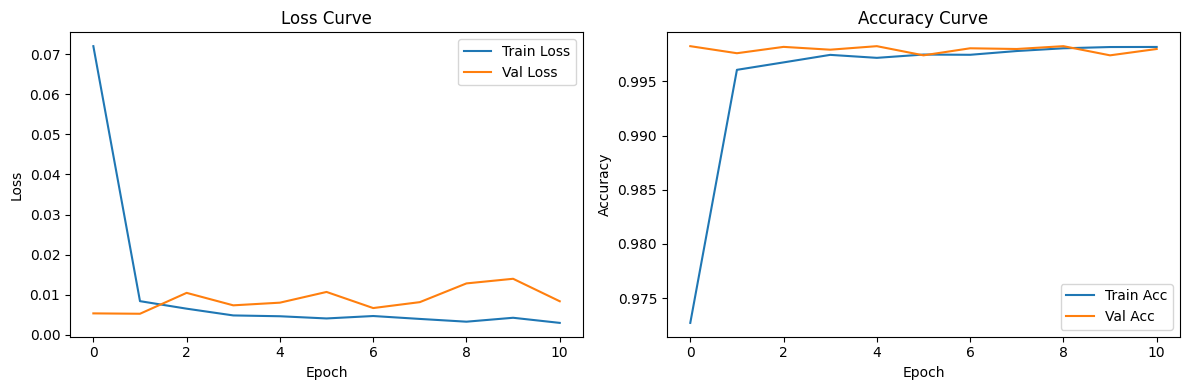

In [17]:
# ✅ FIX 7 — legends added so Train vs Val lines are distinguishable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(train_losses, label='Train Loss')
axes[0].plot(val_losses,   label='Val Loss')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(train_accs, label='Train Acc')
axes[1].plot(val_accs,   label='Val Acc')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

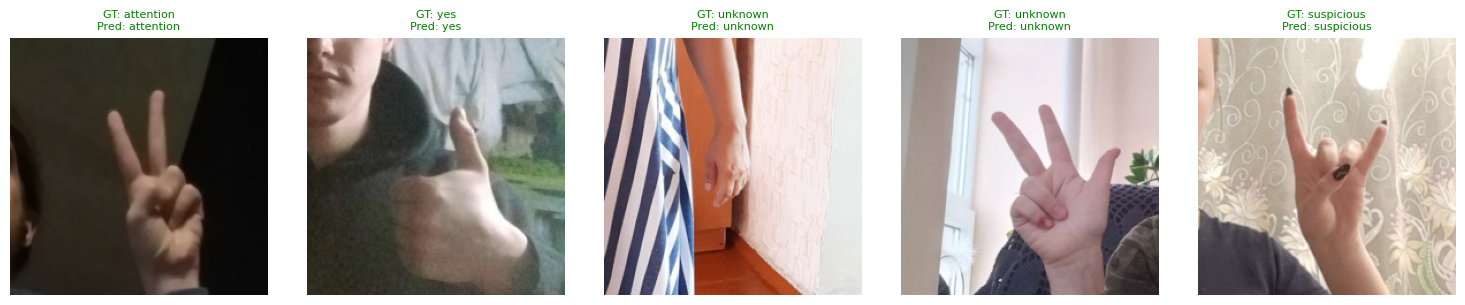

In [18]:
# ✅ FIX 5 — denormalize before display so colours look correct
#            Also shows ground truth vs predicted label in title

mean_t = torch.tensor(MEAN).view(3, 1, 1)
std_t  = torch.tensor(STD).view(3, 1, 1)

def denormalize(img_tensor):
    return (img_tensor * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()

model.eval()
vis_imgs, vis_gt = next(iter(val_loader))
vis_imgs_gpu = vis_imgs[:5].to(device)

with torch.no_grad():
    _, logits = model(vis_imgs_gpu)
    vis_preds = logits.argmax(dim=1).cpu()

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for i in range(5):
    axes[i].imshow(denormalize(vis_imgs[i]))
    gt_name   = CLASSES[vis_gt[i].item()]
    pred_name = CLASSES[vis_preds[i].item()]
    color = 'green' if gt_name == pred_name else 'red'
    axes[i].set_title(f'GT: {gt_name}\nPred: {pred_name}', color=color, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [19]:
torch.save({'model_state_dict': model.state_dict(), 'labels': CLASSES},
           'gesture_model_final.pth')
print('Final model saved.')

Final model saved.


In [20]:
# Save full model object (architecture + weights) — used for quick inference without re-defining the class
torch.save(model, 'gesture_model_full.pt')
print('Full model saved as gesture_model_full.pt')

Full model saved as gesture_model_full.pt


In [21]:
# ✅ FIX 3 (embedding cell) — loop variable renamed to emb_labels
#            so 'labels' (HaGRID class-name list) is never overwritten

embeddings_list = []
emb_labels_list = []

model.eval()
with torch.no_grad():
    for images, emb_labels in val_loader:
        images = images.to(device)
        embeddings, _ = model(images)
        embeddings_list.append(embeddings.cpu())
        emb_labels_list.append(emb_labels)

all_embeddings = torch.cat(embeddings_list)
all_emb_labels = torch.cat(emb_labels_list)

torch.save({'embeddings': all_embeddings, 'labels': all_emb_labels},
           'gesture_embeddings.pt')
print('Embeddings saved ✅ | Shape:', all_embeddings.shape)

Embeddings saved ✅ | Shape: torch.Size([15374, 512])
